In [1]:
import os
import shutil
import logging
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import drive

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')
# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Define Dataset Path
source_dir = "/content/drive/MyDrive/Colab Notebooks/thermal images UL"
output_dir = "/content/drive/MyDrive/Colab Notebooks/thermal_images/thermal_dataset/processed_data_Unet"
# Define classes
classes = ['Blast', 'BLB', 'healthy', 'hispa', 'leaf folder', 'leaf spot']

# Check if dataset is correctly placed
if os.path.exists(source_dir):
    print("Dataset path is correct!")
    print("Classes:", os.listdir(source_dir))  # Should list the 6 classes
else:
    print("Dataset path is incorrect. Check your folder structure.")


Mounted at /content/drive
Dataset path is correct!
Classes: ['BLB', 'hispa', 'Blast', 'healthy', 'leaf spot', 'leaf folder']


In [3]:
def prepare_data(source_dir, output_dir, classes, test_size=0.2, val_size=0.2):
    """Prepare and split the dataset with error handling and logging."""
    splits = ['train', 'validation', 'test']

    # Create directories for splits
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    # Track dataset statistics
    class_counts = {}

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)
        if not os.path.exists(class_dir):
            logger.error(f"Class directory not found: {class_dir}")
            continue

        images = [img for img in os.listdir(class_dir)
                 if img.lower().endswith(('jpg', 'jpeg', 'png'))]

        if not images:
            logger.warning(f"No images found in class: {cls}")
            continue

        class_counts[cls] = len(images)
        image_paths = [os.path.join(class_dir, img) for img in images]

        # Split data
        train_val_images, test_images = train_test_split(
            image_paths, test_size=test_size, random_state=42, shuffle=True)
        train_images, val_images = train_test_split(
            train_val_images, test_size=val_size, random_state=42, shuffle=True)

        # Copy images with error handling
        for img_list, split in [(train_images, 'train'),
                              (val_images, 'validation'),
                              (test_images, 'test')]:
            for img_path in img_list:
                try:
                    shutil.copy(img_path, os.path.join(output_dir, split, cls))
                except Exception as e:
                    logger.error(f"Error copying {img_path}: {str(e)}")

    logger.info("Class distribution:")
    for cls, count in class_counts.items():
        logger.info(f"{cls}: {count} images")

    return class_counts

In [4]:
def create_data_generators(output_dir, img_size=(224, 224), batch_size=32):
    """Create data generators with augmentation."""
    datagen_train = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    datagen_val_test = ImageDataGenerator(rescale=1./255)

    train_generator = datagen_train.flow_from_directory(
        os.path.join(output_dir, 'train'),
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )

    val_generator = datagen_val_test.flow_from_directory(
        os.path.join(output_dir, 'validation'),
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = datagen_val_test.flow_from_directory(
        os.path.join(output_dir, 'test'),
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

In [5]:
def build_efficient_model(input_shape=(224, 224, 3), num_classes=6):
    """Build an EfficientNetB0-based model with transfer learning."""
    base_model = applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze the base model
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')]
    )

    return model

In [6]:
def train_model(model, train_gen, val_gen, epochs=50, class_weights=None):
    """Train the model with callbacks and optional class weights."""
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            'best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]  # Last training accuracy
    val_acc = history.history['val_accuracy'][-1]  # Last validation accuracy

    return history, train_acc, val_acc


In [7]:
def calculate_class_weights(class_counts):
    """Calculate class weights for imbalanced dataset."""
    total = sum(class_counts.values())
    max_samples = max(class_counts.values())
    class_weights = {i: max_samples / count for i, count in enumerate(class_counts.values())}
    return class_weights

def evaluate_model(model, test_generator):
    """Evaluate the model and print detailed metrics."""
    results = model.evaluate(test_generator, verbose=1)
    test_acc = results[1]  # Accuracy is the second value in results

    print("\nTest Results:")
    for metric_name, value in zip(model.metrics_names, results):
        print(f"{metric_name}: {value:.4f}")

    return test_acc


def fine_tune_model(model, train_gen, val_gen, epochs=30):
    """Fine-tune the model by unfreezing some layers."""
    # Unfreeze the top layers of the base model
    base_model = model.layers[0]
    base_model.trainable = True

    for layer in base_model.layers[:-20]:  # Keep first 20 layers frozen
        layer.trainable = False

    # Recompile with a lower learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')]
    )

    # Train with the same callbacks and return accuracies
    history, train_acc, val_acc = train_model(model, train_gen, val_gen, epochs=epochs)

    return history, train_acc, val_acc


In [8]:
if __name__ == "__main__":

    # Step 1: Prepare Data
    class_counts = prepare_data(source_dir, output_dir, classes)

    # Step 2: Compute Class Weights for Handling Imbalance
    class_weights = calculate_class_weights(class_counts)

    # Step 3: Create Data Generators
    train_gen, val_gen, test_gen = create_data_generators(output_dir)

    # Step 4: Build Model
    model = build_efficient_model()

    logger.info("Training initial model...")

    # Step 5: Train Initial Model and Store Training/Validation Accuracy
    history, train_acc, val_acc = train_model(model, train_gen, val_gen, epochs=30, class_weights=class_weights)

    logger.info(f"Initial Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

    # Step 6: Evaluate Initial Model on Test Data
    logger.info("Evaluating initial model on test data...")
    test_acc = evaluate_model(model, test_gen)
    logger.info(f"Initial Test Accuracy: {test_acc:.4f}")

    # Step 7: Fine-Tune the Model
    logger.info("Fine-tuning the model...")
    fine_tune_history, fine_train_acc, fine_val_acc = fine_tune_model(model, train_gen, val_gen)

    logger.info(f"Fine-Tuned Training Accuracy: {fine_train_acc:.4f}, Validation Accuracy: {fine_val_acc:.4f}")

    # Step 8: Final Evaluation on Test Data
    logger.info("Final model evaluation on test data...")
    final_test_acc = evaluate_model(model, test_gen)
    logger.info(f"Final Test Accuracy: {final_test_acc:.4f}")

    # Step 9: Save the Final Model
    model.save('final_thermal_classification_model.h5')
    logger.info("Final model saved successfully!")


Found 528 images belonging to 6 classes.
Found 200 images belonging to 6 classes.
Found 228 images belonging to 6 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1903 - loss: 7.7327 - top2_acc: 0.3554
Epoch 1: val_accuracy improved from -inf to 0.03000, saving model to best_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - accuracy: 0.1910 - loss: 7.7196 - top2_acc: 0.3551 - val_accuracy: 0.0300 - val_loss: 1.8953 - val_top2_acc: 0.1700 - learning_rate: 0.0010
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.1783 - loss: 6.9720 - top2_acc: 0.3345
Epoch 2: val_accuracy improved from 0.03000 to 0.46500, saving model to best_model.h5


17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 524ms/step - accuracy: 0.1789 - loss: 6.9605 - top2_acc: 0.3358 - val_accuracy: 0.4650 - val_loss: 1.6912 - val_top2_acc: 0.4950 - learning_rate: 0.0010
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.1675 - loss: 6.2908 - top2_acc: 0.3637
Epoch 3: val_accuracy did not improve from 0.46500
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 550ms/step - accuracy: 0.1696 - loss: 6.2902 - top2_acc: 0.3649 - val_accuracy: 0.4650 - val_loss: 1.5865 - val_top2_acc: 0.6750 - learning_rate: 0.0010
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.2094 - loss: 5.9970 - top2_acc: 0.4200
Epoch 4: val_accuracy did not improve from 0.46500
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 549ms/step - accuracy: 0.2107 - loss: 6.0036 - top2_acc: 0.4196 - val_accuracy: 0.4650 - val_loss: 1.5469 - val_top2_acc: 0.6750 - learning_rate: 0.0010
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.2287 - loss: 5.4121 - top2_acc: 0.4506
Epoch 5: val_accuracy did not impr

17/17 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.2209 - loss: 2.7696 - top2_acc: 0.3775 - val_accuracy: 0.4650 - val_loss: 1.6681 - val_top2_acc: 0.4950 - learning_rate: 1.0000e-05
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.2112 - loss: 2.8459 - top2_acc: 0.3583
Epoch 2: val_accuracy did not improve from 0.46500
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 506ms/step - accuracy: 0.2115 - loss: 2.8452 - top2_acc: 0.3581 - val_accuracy: 0.4650 - val_loss: 1.6471 - val_top2_acc: 0.4950 - learning_rate: 1.0000e-05
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.1831 - loss: 2.7701 - top2_acc: 0.3746
Epoch 3: val_accuracy did not improve from 0.46500
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 556ms/step - accuracy: 0.1833 - loss: 2.7696 - top2_acc: 0.3729 - val_accuracy: 0.4650 - val_loss: 1.6316 - val_top2_acc: 0.4950 - learning_rate: 1.0000e-05
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.1928 - loss: 2.6624 - top2_acc: 0.3524
Epoch 4: val_accuracy di


Test Results:
loss: 1.6987
compile_metrics: 0.4342


✅ Training Accuracy: 20.27%
✅ Validation Accuracy: 46.50%
✅ Test Accuracy: 43.42%


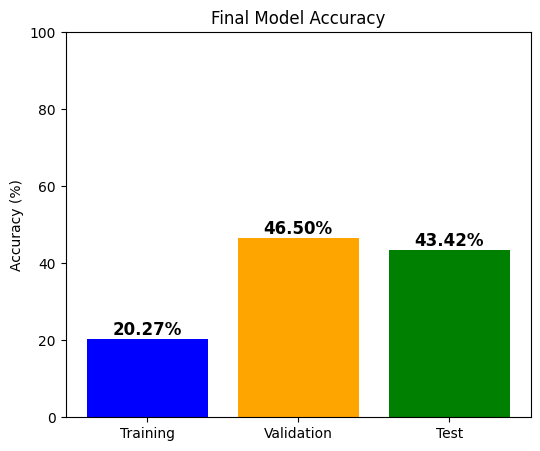

In [10]:
import matplotlib.pyplot as plt

def plot_accuracy_summary(train_acc, val_acc, test_acc):
    # Print the accuracy summary in text format
    print(f"✅ Training Accuracy: {train_acc:.2f}%")
    print(f"✅ Validation Accuracy: {val_acc:.2f}%")
    print(f"✅ Test Accuracy: {test_acc:.2f}%")

    # Plot bar chart
    accuracies = [train_acc, val_acc, test_acc]
    labels = ["Training", "Validation", "Test"]
    colors = ['blue', 'orange', 'green']

    plt.figure(figsize=(6, 5))
    plt.bar(labels, accuracies, color=colors)
    plt.ylim(0, 100)  # Accuracy range from 0 to 100%
    plt.ylabel("Accuracy (%)")
    plt.title("Final Model Accuracy")

    # Show accuracy values on top of bars
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontsize=12, fontweight='bold')

    plt.show()

# Call this function after model evaluation
plot_accuracy_summary(fine_train_acc * 100, fine_val_acc * 100, final_test_acc * 100)
